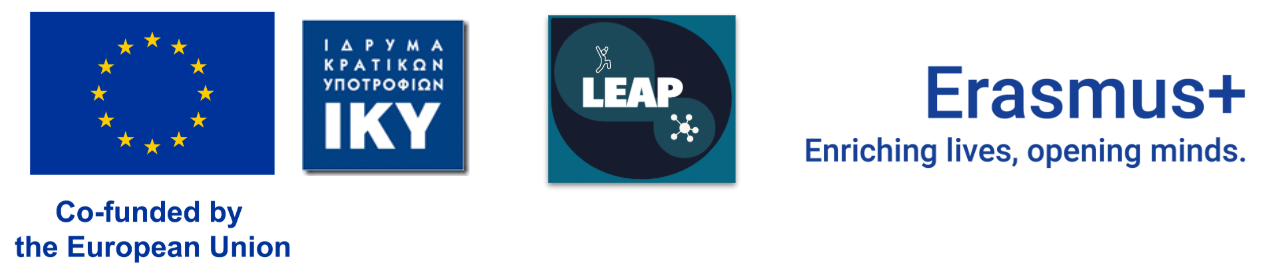

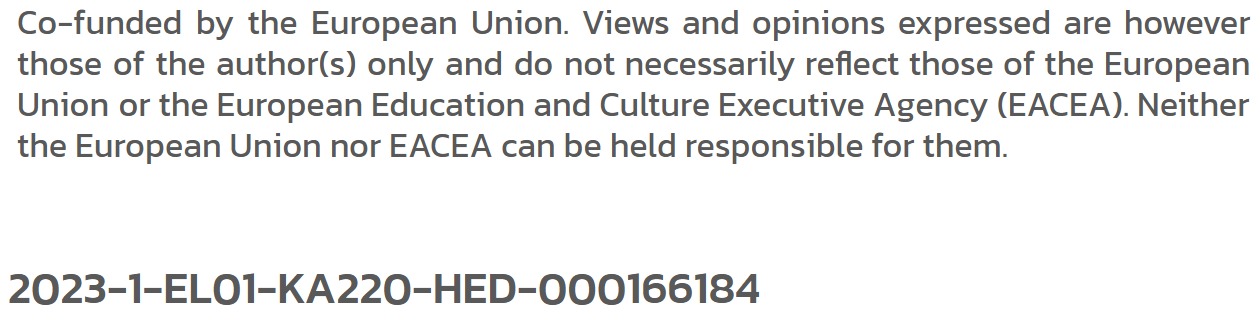

# Final Project, Option 2: Does a neural network beat a classical model?

A public agency wants to flag likely higher-income households from survey data, so that an outreach programme can be targeted, and it must choose between a simple, explainable model and a more complex neural network. In this project you build both and judge whether the added complexity is worthwhile.

In this project you build two classifiers for the same real data set, then compare them fairly.

**Central question:** does a neural network beat a well-built classical model on this data set?

The data set is Adult, also called Census Income. Each row describes one person, with a mix of numeric features (such as age and hours worked per week) and categorical features (such as occupation and education). The task is to predict whether that person earns more than 50,000 dollars a year.

This project draws on two earlier modules. In Module 3, we built a preprocessing and modelling pipeline in scikit-learn, using a ColumnTransformer to impute missing values, scale the numeric features, and one-hot encode the categorical ones, and we judged the result with cross-validation. In Module 5, we built and trained dense neural networks in Keras. Here you build one of each on the same features and see which does better.

**How this notebook is organised.** The cells in Part A are already written for you. They handle the import, the download, the target encoding, the train and test split, and the detection of which columns are numeric and which are categorical. From Part B onward, the cells are yours to complete. Each one carries comments describing what to do, along with a few hints, but not the finished code. Work through them in order.

## Part A. Setup and data

We start with the imports. This cell loads everything the notebook needs, so we run it once at the top.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)

import keras
from keras import layers

### Loading the data

We download the Adult data set from OpenML. The features arrive in `X` as a table, and the target in `y` as text, either `>50K` or `<=50K`. The download runs once and may take a moment.

In [2]:
X, y = fetch_openml("adult", version=2, as_frame=True, return_X_y=True)

print("Rows and columns:", X.shape)
print("Target values:", y.value_counts().to_dict())
X.head()

Rows and columns: (48842, 14)
Target values: {'<=50K': 37155, '>50K': 11687}


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States


### Encoding the target

The target is text with two values. We convert it to numbers so both models can use it. `LabelEncoder` maps the two classes to 0 and 1 in alphabetical order, so `<=50K` becomes 0 and `>50K` becomes 1. The higher income class is therefore the positive class, labelled 1.

In [3]:
y = LabelEncoder().fit_transform(y)
print("Positive rate (share earning >50K):", round(y.mean(), 3))

Positive rate (share earning >50K): 0.239


### Train and test split

We split the data into a training set and a test set before doing anything else, and we keep the class balance with `stratify`, exactly as in Module 3. Both models are trained on the training set and judged on the same held-back test set, so the comparison is fair.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Training rows:", X_train.shape[0])
print("Test rows:    ", X_test.shape[0])

Training rows: 39073
Test rows:     9769


### Numeric and categorical columns

The two kinds of feature need different preprocessing, so we sort the columns into a numeric group and a categorical group. We detect them from the column data types.

In [5]:
numeric_features = X_train.select_dtypes(include="number").columns.tolist()
categorical_features = X_train.select_dtypes(exclude="number").columns.tolist()

print("Numeric features:    ", numeric_features)
print("Categorical features:", categorical_features)

Numeric features:     ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical features: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


## Part B. The classical model

From here on, the cells are yours to complete.

First, build the preprocessing step, the same idea you used in Module 3. Numeric and categorical columns are handled by separate small pipelines, then joined with a ColumnTransformer.

In [6]:
# Build the preprocessor with a ColumnTransformer.
#
# For the NUMERIC columns, chain two steps in a Pipeline:
#   - SimpleImputer to fill missing values (strategy="median" is sensible here)
#   - StandardScaler to put the features on the same scale
#
# For the CATEGORICAL columns, chain two steps in a Pipeline:
#   - SimpleImputer to fill missing values (strategy="most_frequent")
#   - OneHotEncoder to turn categories into numbers. Set
#       handle_unknown="ignore"  so unseen categories in the test set do not error
#       sparse_output=False       so the result is a plain array the network can use later
#
# Then combine the two with a ColumnTransformer, applying each pipeline
# to its own list of columns (numeric_features and categorical_features).
#

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer([
    ("numeric", numeric_pipe, numeric_features),
    ("categorical", categorical_pipe, categorical_features)
])


### The full pipeline

Wrap the preprocessor and a classifier into a single pipeline. We use `LogisticRegression`, the classifier from Module 3.

In [7]:
# Combine the preprocessor and a LogisticRegression into one Pipeline,
# so that preprocessing is fitted only on the training data inside each fold.
# LogisticRegression(max_iter=1000) gives it enough iterations to converge.
#

clf = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=1000))
])


### Cross-validation

Before the final test, estimate performance with cross-validation on the training data, as in Module 3. A single split can be lucky or unlucky; averaging over folds gives a steadier estimate.

In [8]:
# Run 5-fold cross-validation on the TRAINING data, scoring by F1.
# Use StratifiedKFold(n_splits=5, shuffle=True, random_state=42).
#

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring="f1")

print("F1 per fold:", cv_scores)
print("Mean F1:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())


F1 per fold: [0.67144564 0.66647111 0.65281899 0.64542531 0.65165253]
Mean F1: 0.6575627160793569
Standard deviation: 0.009765702361915582


### Fit and evaluate on the test set

Now fit the pipeline on the whole training set and judge it on the test set. Record the accuracy and the F1 score, and draw the confusion matrix. Keep these numbers; you will compare them with the network in Part D.

Logistic Regression Accuracy: 0.8524
Logistic Regression F1: 0.6562


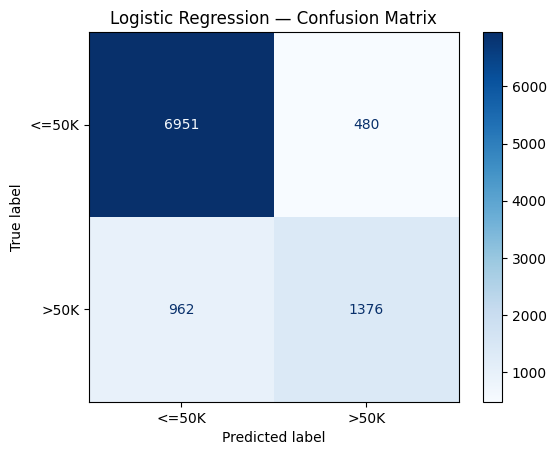

In [9]:
# Fit clf on the training data, then predict on the test data.
# Store the results so you can compare them later:
#   clf_acc = accuracy_score(...)
#   clf_f1  = f1_score(...)
# Then draw the confusion matrix for the classical model.
#

clf.fit(X_train, y_train)

clf_pred=clf.predict(X_test)

clf_acc=accuracy_score(y_test, clf_pred)
clf_f1=f1_score(y_test, clf_pred)

print("Logistic Regression Accuracy:", np.round(clf_acc, 4))
print("Logistic Regression F1:", np.round(clf_f1, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    clf_pred,
    display_labels=["<=50K", ">50K"],
    cmap="Blues"
)
plt.title("Logistic Regression — Confusion Matrix")
plt.show()



## Part C. The neural network

Before building the neural network, make a prediction. Do you expect its F1 score to be higher than, lower than, or similar to that of logistic regression? Do you expect a large or a small difference? Briefly explain your reasoning.

I expect the neural network to achieve a slightly higher F1 score than logistic regression. Logistic regression misses many higher-income examples, so there is room for improvement. The neural network may capture useful nonlinear relationships between features. However, it will still learn from the same imbalanced dataset, so I expect the improvement to be small.

A neural network needs a plain numeric array as input, so we apply the preprocessor to turn the mixed table into numbers. We fit the preprocessor on the training data only, then transform both sets, so no information leaks from the test set.

In [10]:
# Turn the tables into numeric arrays the network can read.
#   X_train_prep = preprocess.fit_transform(X_train)   # fit on training data only
#   X_test_prep  = preprocess.transform(X_test)         # reuse the same fitting
# Then print X_train_prep.shape so you know how many input features the network needs.

X_train_prep = preprocess.fit_transform(X_train)
X_test_prep = preprocess.transform(X_test)

print("Preprocessed training shape:", X_train_prep.shape)


Preprocessed training shape: (39073, 105)


### Build the network

Build a small dense network for this feature array, in the Sequential style from Module 5. The task is binary, so the output is a single unit with a sigmoid activation, giving the probability of the positive class.

In [11]:
# Build a dense network with the Keras Sequential API.
#   - an Input layer whose shape is the number of columns in X_train_prep
#     (use X_train_prep.shape[1])                                 [given below]
#   - a Dense hidden layer (try 64 units, relu)
#   - a Dropout layer (0.3) to reduce overfitting
#   - a second Dense hidden layer (try 32 units, relu)
#   - a Dense output layer with 1 unit and a sigmoid activation

net = keras.Sequential([
    layers.Input(shape=(X_train_prep.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

net.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         6,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,897 (34.75 KB)

 Trainable params: 8,897 (34.75 KB)

 Non-trainable params: 0 (0.00 B)

### Compile and train

Compile and train the network. Because the output is a single sigmoid unit, the loss is `binary_crossentropy`. Use EarlyStopping so training stops once the validation loss stops improving.

In [12]:
# Compile net with:
#   optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"]
# Then train it with:
#   validation_split=0.1, an EarlyStopping callback (monitor "val_loss",
#   patience about 3, restore_best_weights=True), up to about 20 epochs,
#   and batch_size=128. Store the result in history.

net.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

early_stop=keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

history=net.fit(X_train_prep, y_train, validation_split=0.1, epochs=20, batch_size=128, callbacks=[early_stop])


Epoch 1/20
275/275 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8221 - loss: 0.3759 - val_accuracy: 0.8506 - val_loss: 0.3267
Epoch 2/20
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8506 - loss: 0.3210 - val_accuracy: 0.8529 - val_loss: 0.3236
Epoch 3/20
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8530 - loss: 0.3136 - val_accuracy: 0.8539 - val_loss: 0.3244
Epoch 4/20
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8543 - loss: 0.3104 - val_accuracy: 0.8539 - val_loss: 0.3270
Epoch 5/20
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8565 - loss: 0.3075 - val_accuracy: 0.8521 - val_loss: 0.3264


### Evaluate on the test set

Judge the network on the same test set. The network outputs probabilities, so a prediction is positive when the probability is above 0.5. Record the accuracy and F1, and draw the confusion matrix.

306/306 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Neural Network Accuracy: 0.8558
Neural Network F1: 0.6644


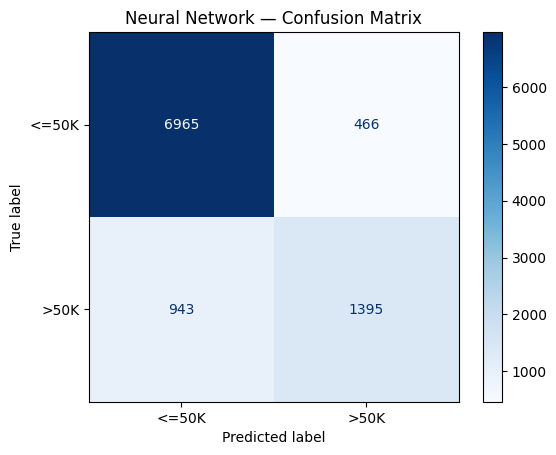

In [13]:
# Produce predictions and evaluate the network.
#   nn_prob = net.predict(X_test_prep).ravel()     # probabilities
#   nn_pred = (nn_prob > 0.5).astype(int)           # threshold at 0.5
# Then compute nn_acc and nn_f1, print them, and draw the confusion matrix.

nn_prob=net.predict(X_test_prep).ravel()
nn_pred=(nn_prob>0.5).astype(int)

nn_acc=accuracy_score(y_test, nn_pred)
nn_f1=f1_score(y_test, nn_pred)

print("Neural Network Accuracy:", np.round(nn_acc, 4))
print("Neural Network F1:", np.round(nn_f1, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    nn_pred,
    display_labels=["<=50K", ">50K"],
    cmap="Blues"
)
plt.title("Neural Network — Confusion Matrix")
plt.show()


## Part D. The comparison

Now answer the central question. You have four numbers: the accuracy and F1 of the classical model, and the accuracy and F1 of the network, all measured on the same test set. Because the higher-income class is the minority class, use F1 as your main comparison metric and accuracy as supporting information.

In [14]:
# Compare the two models side by side.
# Print clf_acc and clf_f1 next to nn_acc and nn_f1, or draw a small bar chart.
# Lead with F1 in your comparison, but report both metrics.

comparison=pd.DataFrame({
    "Model": ["Logistic Regression", "Neural Network"],
    "F1": [clf_f1, nn_f1],
    "Accuracy": [clf_acc, nn_acc],
})

display(comparison.round(4))


,Model,F1,Accuracy
0,Logistic Regression,0.6562,0.8524
1,Neural Network,0.6644,0.8558


### Ethical considerations

This data set includes attributes such as sex, race, and nationality, and the target is a person's income bracket. A model that predicts income from these features can easily reproduce and entrench existing inequalities.

**Write two or three sentences here** on the ethical risks of deploying such a model. Consider fairness across the groups in the data, the different real-world costs of a false positive and a false negative in the setting above, and whether a simpler, more transparent model is preferable to an opaque one when decisions affect people.

Before deployment, I would examine group representation and error rates across sex, race and nationality groups, because overall performance can hide unequal outcomes. If a higher-income prediction were used to deny financial support, false positives could unfairly exclude lower-income people, while false negatives could direct support towards higher-income people. Although the neural network produced fewer errors of both types in this run, I would retain logistic regression because the performance gain was small and its decisions are easier to explain; XAI could support transparency but would not by itself establish fairness.


## Wrapping up

Bring your findings together. **Write a short paragraph** that answers the central question directly:

- Which model had the higher F1 score, and by how much? Did accuracy lead to the same conclusion?
- Why would accuracy alone be insufficient for this data set?
- Use the confusion matrices to compare false negatives and false positives. Which model identified the higher-income class more successfully?
- The network has far more moving parts than logistic regression. On this data set, was that extra complexity worth it?
- Considering the size and structure of this tabular data set, suggest one reason why one model may have performed better than the other.

**What to hand in:** this completed notebook, with both confusion matrices and the Part D comparison visible in the output, your prediction in Part C, and your written answer in this cell.

In the final saved run, the neural network achieved a higher F1 score than logistic regression: 0.6644 versus 0.6562, an improvement of approximately 0.008. Accuracy also increased, from 85.24% to 85.58%. Accuracy alone is insufficient because approximately 76% of the examples belong to the lower-income class. The neural network reduced false negatives from 962 to 943 and false positives from 480 to 466, identifying more higher-income individuals while making fewer incorrect positive predictions. With tens of thousands of examples and a mixture of numerical and categorical features, the network may have benefited from learning nonlinear interactions through its ReLU layers, although this experiment does not establish the cause of the improvement. I would still retain logistic regression because I value its simpler interpretation and consider the observed performance gain too small to justify the additional complexity for this use case. This preference does not mean that logistic regression achieved better predictive results, and the observed differences do not establish consistent superiority across repeated runs.
